In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from scipy.optimize import OptimizeWarning
import matplotlib.pyplot as plt
import seaborn as sns
# 忽略 OptimizeWarning
warnings.simplefilter("ignore", OptimizeWarning)

# Set the random seed for reproducibility
seed = 42
np.random.seed(seed)

# Load the dataset
file_path = 'Bitcoinclose.xlsx'  
data = pd.read_excel(file_path)

# Convert the 'Date' column to datetime
data['date'] = pd.to_datetime(data['date'])

# Reverse the data to make it chronological (from old to new)
data = data[::-1].reset_index(drop=True)

# Fill missing values using forward fill (ffill) method
data.fillna(method='ffill', inplace=True)

# Use only the 'close' for prediction (univariate time series)
y = data['close'].values

# Ensure no NaN or inf values in y
if np.any(np.isnan(y)) or np.any(np.isinf(y)):
    print("Warning: NaN or inf detected in the data. Replacing with a suitable value.")
    y = np.nan_to_num(y)  # Replace NaN or inf with 0

# Normalize the target variable using MinMaxScaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Define time index as the independent variable (X)
X = np.array(range(len(y))).reshape(-1, 1)  # Reshape for scikit-learn compatibility

# Ensure no NaN or inf values in X
if np.any(np.isnan(X)) or np.any(np.isinf(X)):
    print("Warning: NaN or inf detected in the data. Replacing with a suitable value.")
    X = np.nan_to_num(X)  # Replace NaN or inf with 0


from scipy.optimize import curve_fit

def exp_func(x, a, b):
    return a * np.exp(b * x)

# Use the first and last data points to fit the model
x_data = np.array([0, len(y) - 1])  # First and last data points
y_data = np.array([y[0], y[-1]])  # Corresponding values

# Fit the exponential curve
params, covariance = curve_fit(exp_func, x_data, y_data, p0=(1, 0.001))

# Get the fitted exponential model
a, b = params

# Generate predicted values for the entire dataset based on the fitted model
y_pred = exp_func(np.arange(len(y)), a, b)

# Calculate evaluation metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = np.mean(np.abs((y - y_pred) / y)) * 100
r2 = r2_score(y, y_pred)





Mean Squared Error (MSE): 298149006.0464
Root Mean Squared Error (RMSE): 17266.9918
MAPE (Mean Absolute Percentage Error): 77.6417%
Mean Absolute Error (MAE): 12497.9095
R² Score: -0.0348


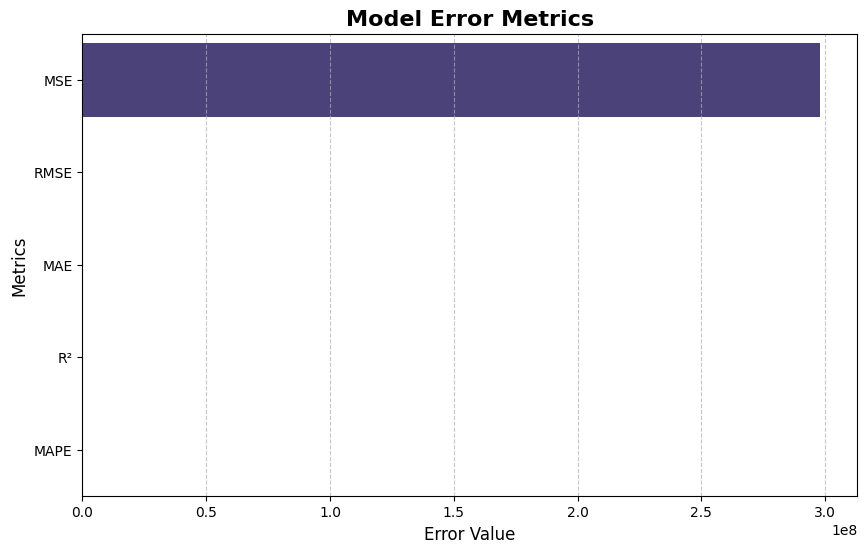

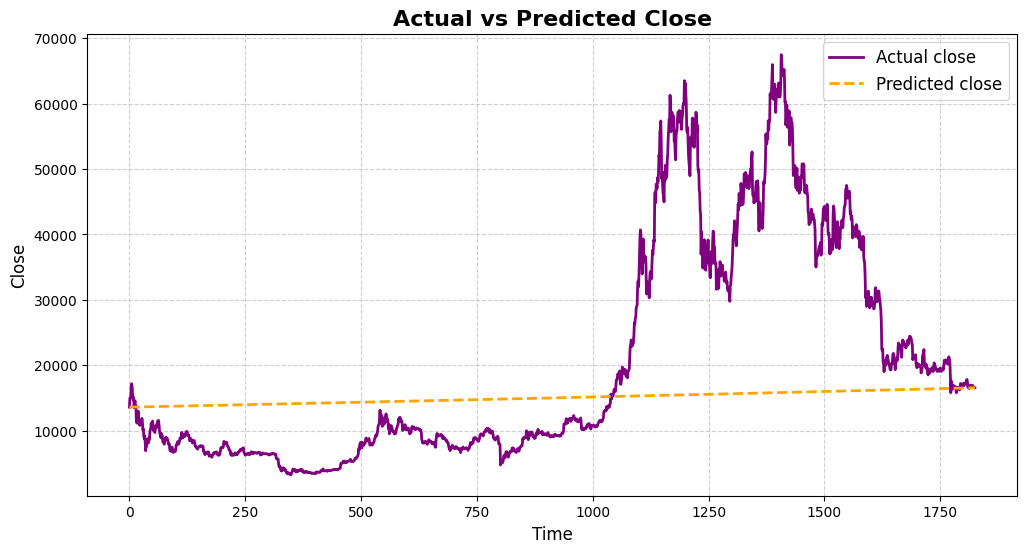

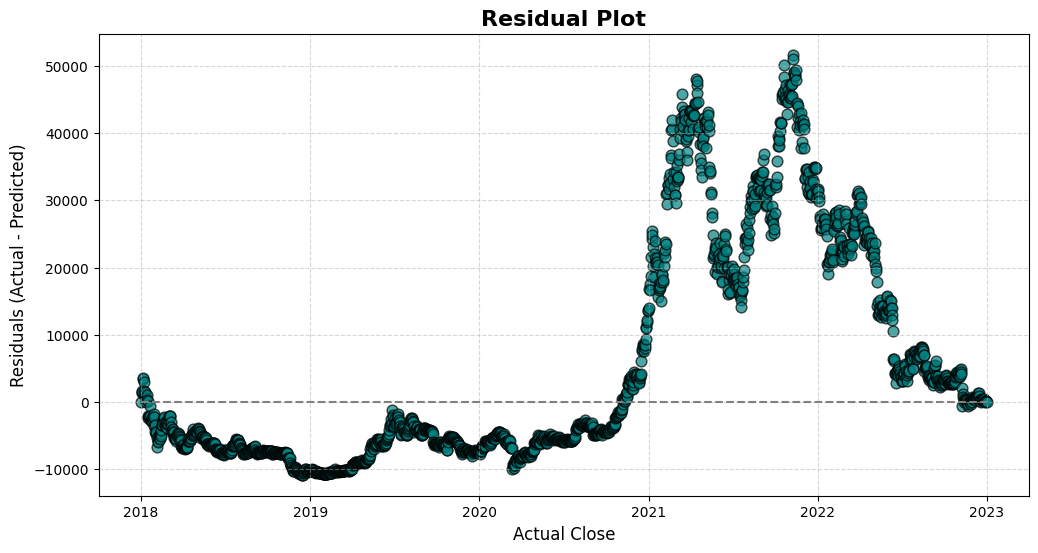

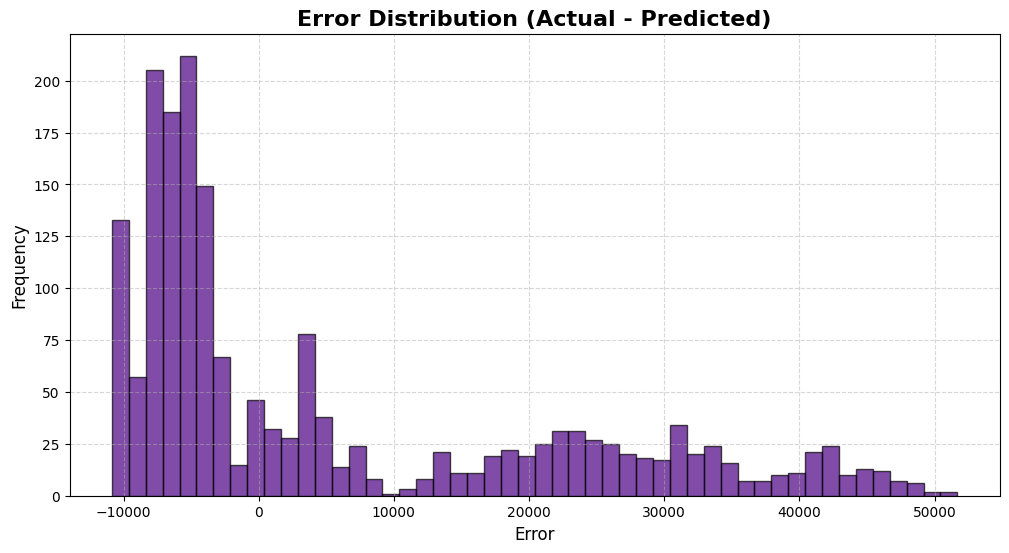

In [26]:
# Output the metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'MAPE (Mean Absolute Percentage Error): {mape:.4f}%')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# Visualization of Metrics (Bar Chart)
metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()), palette='viridis')  # Updated color palette
plt.title('Model Error Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Error Value', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Actual vs Predicted (Line Plot)
plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual close', color='purple', linewidth=2)  # Changed color to purple
plt.plot(y_pred, label='Predicted close', color='orange', linestyle='--', linewidth=2)  # Changed color to orange
plt.title('Actual vs Predicted Close', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Plot
residuals = y - y_pred
plt.figure(figsize=(12, 6))
plt.scatter(data['date'], residuals, color='teal', edgecolor='black', alpha=0.7, s=60)  # Changed color to teal
plt.hlines(y=0, xmin=data['date'].min(), xmax=data['date'].max(), color='gray', linestyle='--', linewidth=1.5)  # Changed color to gray
plt.title('Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Actual Close', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Error Distribution (Histogram)
errors = residuals
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, color='indigo', edgecolor='black', alpha=0.7)  # Changed color to indigo
plt.title('Error Distribution (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()